# Defiining color thresholds for background segmentation

In this tutorial we'll go over how to adjust the color thresholds for fruit background segmentation in `FruitExternalAnalyzer`. 

In [1]:
import traitly
print(f'Traitly version used in this tutorial: {traitly.__version__}')

# Import External Analysis Class
from traitly.fruit_phenotyping import FruitExternalAnalyzer

Traitly version used in this tutorial: 0.1.0


## Blue background

By default `FruitExternalAnalyzer.generate_fruit_mask()` assumes a blue background. Also, it has pre-configured thresholds for `'white'` and `'black'` backgrounds. However, custom thresholds can also by provided manually. For more details, see section [External Analyzer Class](../workflow/external_class.md#generate_fruit_mask).

> **Note**: Although  `FruitInternalAnalyzer` expects a black background, segmenting images with a different background color works the same way as shown here.


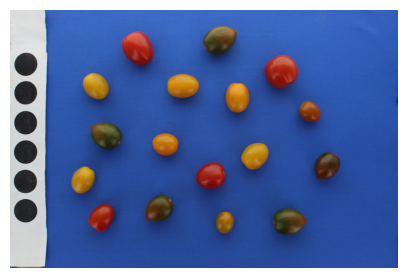

In [2]:
path = './Test_10.png'
blue_example = FruitExternalAnalyzer(path)
blue_example.load_image()
blue_example.setup_measurements(verbose = False)

Since the **blue** its the default color, no additional arguments are needed for `generate_fruit_mask()` for this image. 

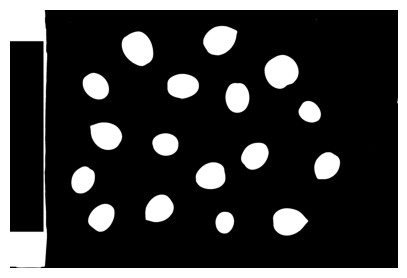

In [3]:
blue_example.generate_fruit_mask()

We can verify the number of detected contours and their locations by setting `plot=True` in `detect_fruits()`.


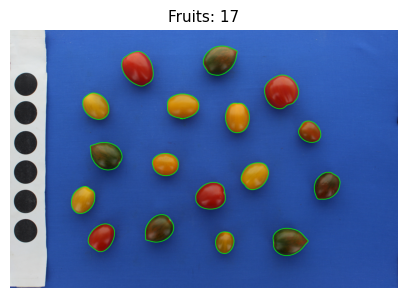


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 17 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_fruit_area: 500


In [4]:
blue_example.detect_fruits(plot = True, contour_thickness = 8)

## Gray background

In this second example we have an image with a gray background. Since gray is not one of the pre-configured colors, we'll define **custom HSV thresholds** manually. To help with this, we can use `generate_color_scatterplots()`, which displays the pixel colors (10,000 pixels by default) of the whole image in HSV space (see section [External Analyzer Class](../workflow/external_class.md#generate_color_scatterplot) for more details on how this function works). Each point in the plots represents a pixel, colored with its actual **RGB** value. The goal is to identify the [H,S,V] range that covers the grey background pixels.

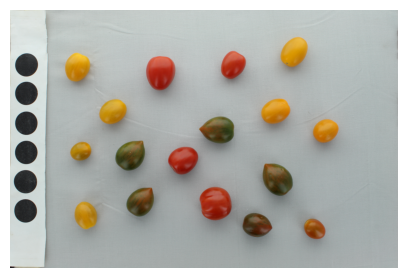

In [5]:
path = './Test_27.png'
gray_example = FruitExternalAnalyzer(path)
gray_example.load_image()
gray_example.setup_measurements(verbose = False)

Here, the **H vs S** and **S vs V** plots seems to be the most informative:

- In **H vs S**, we can see that the grey pixels span the full hue (H) range from 0 to 180, and the most of them have a saturation (S) value below 50 .
- The **S vs V** plot confirms that background pixels cluster within a brightness (V) range of 60–255 and a saturation (S) range of 0–50.

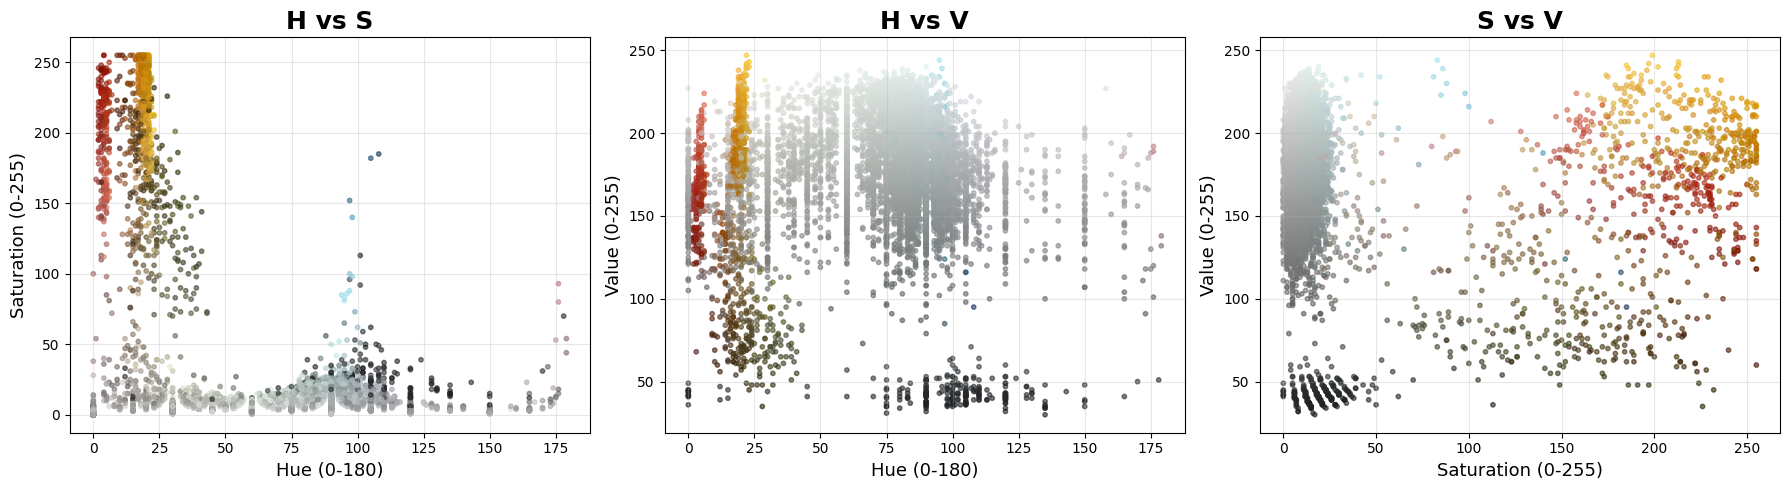

In [68]:
gray_example.generate_color_scatterplot()

From this, we define `lower_color` and `upper_color`, where each value follows the format `[H,S,V]`, and pass them directly to `generate_fruit_mask()`.

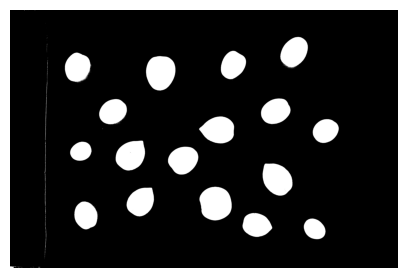

In [ ]:
# hsv_threshold = [H, S, V]
lower_color = [0, 0, 60]
upper_color = [180, 50, 255]

gray_example.generate_fruit_mask(lower_hsv = lower_color, 
                                 upper_hsv = upper_color)

We verify with `detect_fruits()` that the fruits are correctly segmented. In this case, since some fruits were less circular than the ones in the previous image, we slightly reduced the circularity threshold from 0.5 (default) to 0.3.

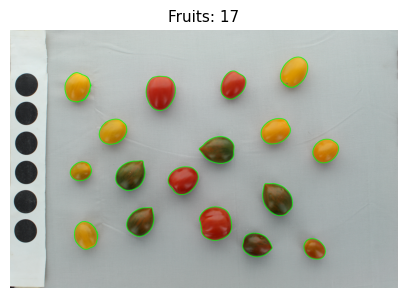


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 17 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.3
        - min_fruit_area: 500


In [ ]:
gray_example.detect_fruits(plot = True, 
                           contour_thickness = 8, 
                           min_fruit_circularity = 0.3)

## White background

Finally, we have an example with a white background. Since `white` is a pre-configured color, we can simply use `background_color='white'` in `generate_fruit_mask()`.

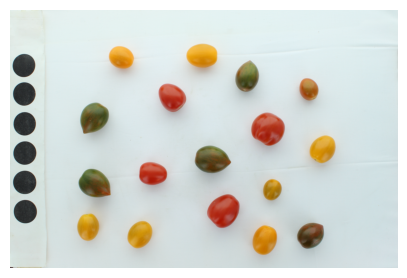

In [ ]:
path = './Test_56.png'
white_example = FruitExternalAnalyzer(path)
white_example.load_image()
white_example.setup_measurements(verbose = False)

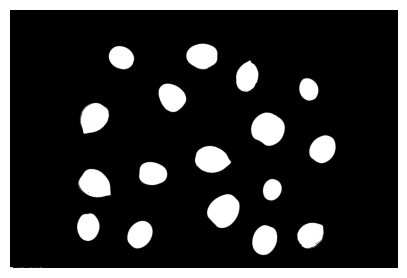

In [4]:
white_example.generate_fruit_mask(background_color = 'white')

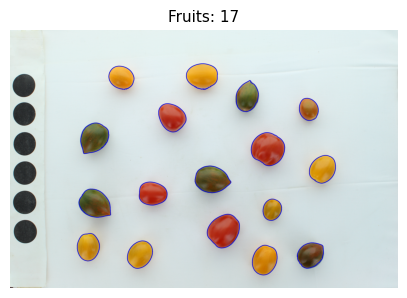


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 17 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.3
        - min_fruit_area: 500


In [ ]:
white_example.detect_fruits(plot = True, 
                            contour_thickness = 8, 
                            contour_color = (0,0,220), 
                            min_fruit_circularity = 0.3)